In [32]:
!pip install pandas matplotlib seaborn wordcloud

In [33]:
import pandas as pd
import json

with open("/kaggle/input/datasets/adityamaj20051004/dataset2/watch-history.json", "r", encoding="utf-8") as f:
    data = json.load(f)

print(type(data))
print(len(data))

<class 'list'>
4500


In [34]:
df = pd.DataFrame(data)

df.head()

,header,title,titleUrl,subtitles,time,products,activityControls
0,YouTube,Watched মাদ্রাসায় Vande Mataram ! 'আমরা সিদ্ধা...,https://www.youtube.com/watch?v=__9pXNTYb3E,"[{'name': 'Aaj Tak Bangla', 'url': 'https://ww...",2026-05-22T07:19:09.868Z,[YouTube],[YouTube watch history]
1,YouTube,Watched 😭BLURRED COPIES+SITE NOT WORKING 💔#cbs...,https://www.youtube.com/watch?v=3kptOVnxEsY,"[{'name': 'Shree', 'url': 'https://www.youtube...",2026-05-22T07:18:28.031Z,[YouTube],[YouTube watch history]
2,YouTube,Watched Bengal Makes Vande Mataram Mandatory I...,https://www.youtube.com/watch?v=WVWICiQ_paI,"[{'name': 'India Today', 'url': 'https://www.y...",2026-05-22T07:17:45.175Z,[YouTube],[YouTube watch history]
3,YouTube,Watched Cockroach Janta Party Anthem song CJP2026,https://www.youtube.com/watch?v=Wvqe-lIYLOE,"[{'name': 'Pawan Meghwanshi official ', 'url':...",2026-05-22T07:17:08.216Z,[YouTube],[YouTube watch history]
4,YouTube,Watched It's time to set Bangladesh Fielding🤣🚩...,https://www.youtube.com/watch?v=M6pTkLSnSJ8,"[{'name': 'Bharat Matters ', 'url': 'https://w...",2026-05-22T07:16:46.124Z,[YouTube],[YouTube watch history]


In [35]:
df["channel"] = df["subtitles"].apply(
    lambda x: x[0]["name"] if isinstance(x, list) and len(x) > 0 else None
)

df["time"] = pd.to_datetime(
    df["time"],
    format="mixed"
)

df["title_clean"] = df["title"].str.replace(
    "Watched ",
    "",
    regex=False
)

df = df[[
    "title_clean",
    "channel",
    "time",
    "titleUrl"
]]

df.head()

,title_clean,channel,time,titleUrl
0,মাদ্রাসায় Vande Mataram ! 'আমরা সিদ্ধান্ত মানব...,Aaj Tak Bangla,2026-05-22 07:19:09.868000+00:00,https://www.youtube.com/watch?v=__9pXNTYb3E
1,😭BLURRED COPIES+SITE NOT WORKING 💔#cbse #cbsec...,Shree,2026-05-22 07:18:28.031000+00:00,https://www.youtube.com/watch?v=3kptOVnxEsY
2,Bengal Makes Vande Mataram Mandatory In School...,India Today,2026-05-22 07:17:45.175000+00:00,https://www.youtube.com/watch?v=WVWICiQ_paI
3,Cockroach Janta Party Anthem song CJP2026,Pawan Meghwanshi official,2026-05-22 07:17:08.216000+00:00,https://www.youtube.com/watch?v=Wvqe-lIYLOE
4,It's time to set Bangladesh Fielding🤣🚩 #suvend...,Bharat Matters,2026-05-22 07:16:46.124000+00:00,https://www.youtube.com/watch?v=M6pTkLSnSJ8


In [36]:
print("Total videos watched:", len(df))

Total videos watched: 4500


In [37]:
top_channels = df["channel"].value_counts().head(10)

print(top_channels)

channel
ABP ANANDA         121
TV9 Bangla         104
Aaj Tak Bangla      75
News18 Bangla       71
Zee 24 Ghanta       71
Republic Bangla     68
Narendra Modi       64
StudyIQ IAS         57
The Lallantop       56
Dainik Bhaskar      40
Name: count, dtype: int64


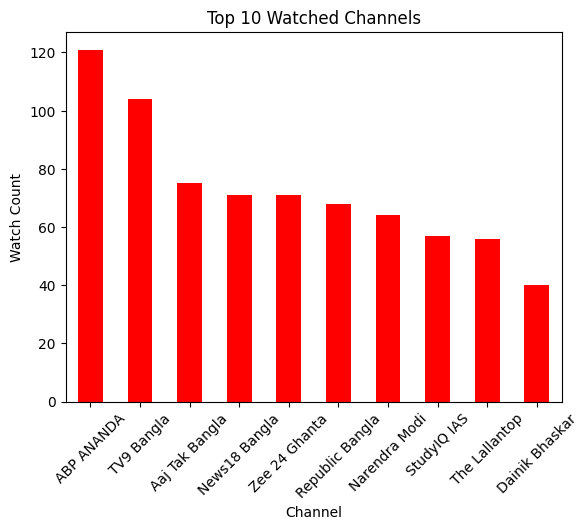

In [38]:
import matplotlib.pyplot as plt

top_channels.plot(kind="bar",color="red")

plt.title("Top 10 Watched Channels")
plt.xlabel("Channel")
plt.ylabel("Watch Count")

plt.xticks(rotation=45)
plt.show()

In [58]:
print(df["time"].dtype)

datetime64[ns, UTC]


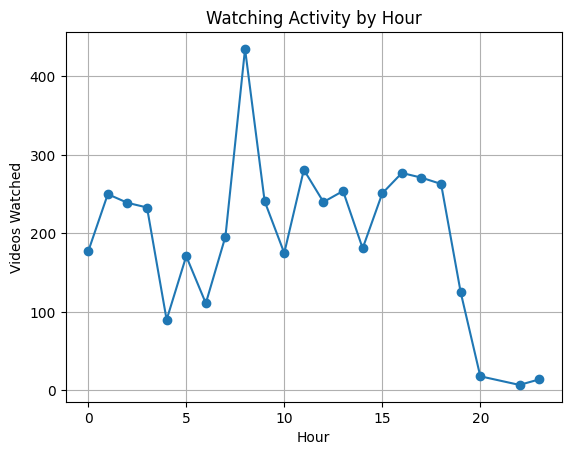

In [41]:
df["hour"] = df["time"].dt.hour

hourly = df["hour"].value_counts().sort_index()

hourly.plot(kind="line", marker="o")

plt.title("Watching Activity by Hour")
plt.xlabel("Hour")
plt.ylabel("Videos Watched")

plt.grid(True)
plt.show()

In [59]:
df.head()

,title_clean,channel,time,titleUrl,hour,date,day,category,year
0,মাদ্রাসায় Vande Mataram ! 'আমরা সিদ্ধান্ত মানব...,Aaj Tak Bangla,2026-05-22 07:19:09.868000+00:00,https://www.youtube.com/watch?v=__9pXNTYb3E,7,2026-05-22,Friday,Other,2026
1,😭BLURRED COPIES+SITE NOT WORKING 💔#cbse #cbsec...,Shree,2026-05-22 07:18:28.031000+00:00,https://www.youtube.com/watch?v=3kptOVnxEsY,7,2026-05-22,Friday,Other,2026
2,Bengal Makes Vande Mataram Mandatory In School...,India Today,2026-05-22 07:17:45.175000+00:00,https://www.youtube.com/watch?v=WVWICiQ_paI,7,2026-05-22,Friday,Other,2026
3,Cockroach Janta Party Anthem song CJP2026,Pawan Meghwanshi official,2026-05-22 07:17:08.216000+00:00,https://www.youtube.com/watch?v=Wvqe-lIYLOE,7,2026-05-22,Friday,Other,2026
4,It's time to set Bangladesh Fielding🤣🚩 #suvend...,Bharat Matters,2026-05-22 07:16:46.124000+00:00,https://www.youtube.com/watch?v=M6pTkLSnSJ8,7,2026-05-22,Friday,Politics,2026


In [42]:
df["hour"] = df["time"].dt.hour

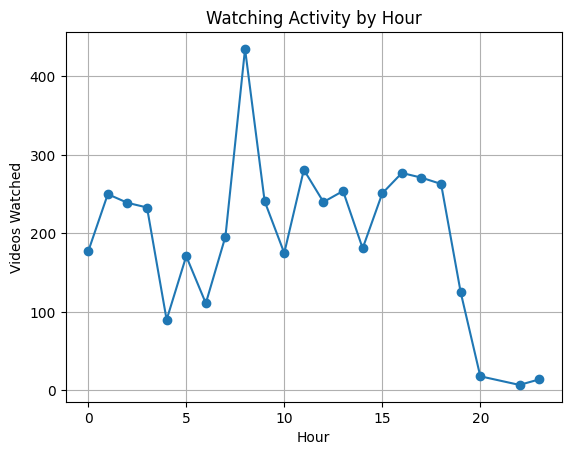

In [43]:
hourly = df["hour"].value_counts().sort_index()

hourly.plot(kind="line", marker="o")

plt.title("Watching Activity by Hour")
plt.xlabel("Hour")
plt.ylabel("Videos Watched")

plt.grid(True)
plt.show()

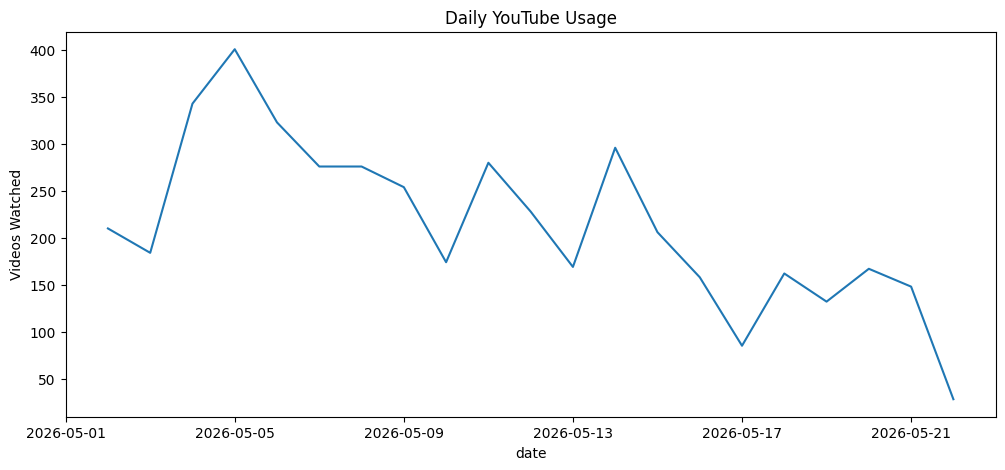

In [44]:
df["date"] = df["time"].dt.date

daily = df.groupby("date").size()

daily.plot(figsize=(12,5))

plt.title("Daily YouTube Usage")
plt.ylabel("Videos Watched")

plt.show()

In [45]:
top_channels = df["channel"].value_counts().head(10)

print(top_channels)

channel
ABP ANANDA         121
TV9 Bangla         104
Aaj Tak Bangla      75
News18 Bangla       71
Zee 24 Ghanta       71
Republic Bangla     68
Narendra Modi       64
StudyIQ IAS         57
The Lallantop       56
Dainik Bhaskar      40
Name: count, dtype: int64


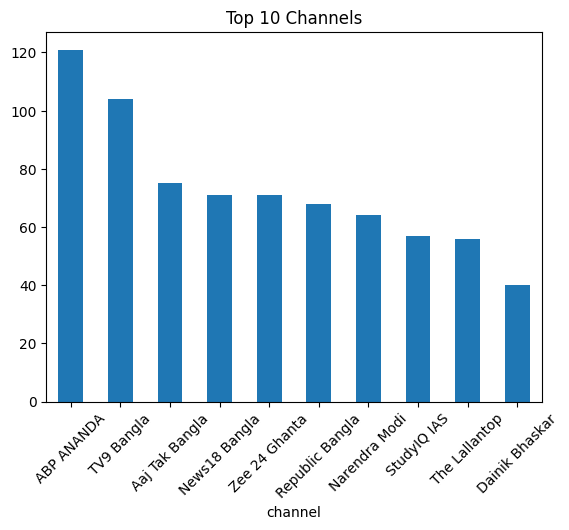

In [46]:
top_channels.plot(kind="bar")

plt.title("Top 10 Channels")
plt.xticks(rotation=45)

plt.show()

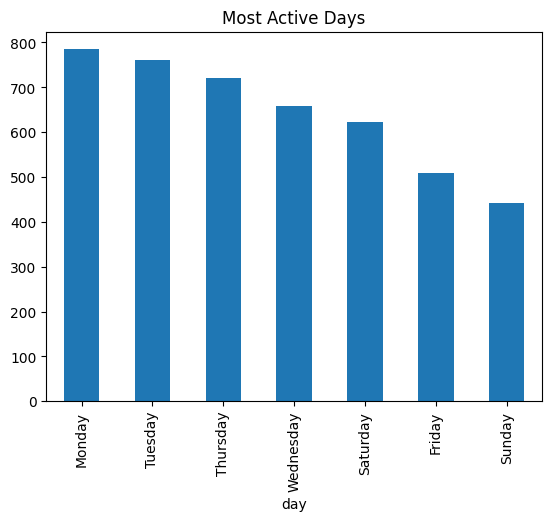

In [47]:
df["day"] = df["time"].dt.day_name()

df["day"].value_counts().plot(kind="bar")

plt.title("Most Active Days")
plt.show()

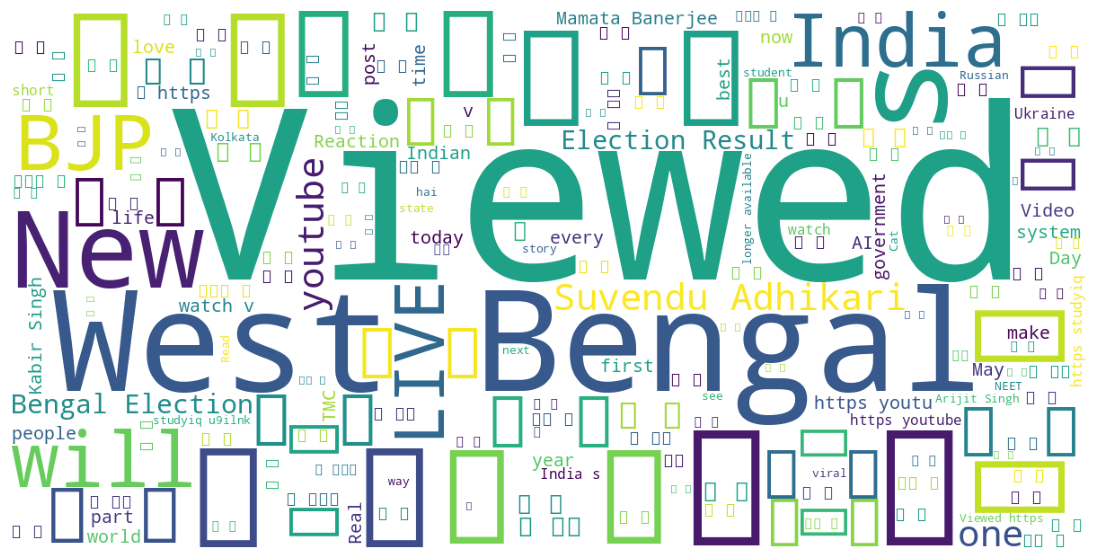

In [48]:
from wordcloud import WordCloud

text = " ".join(df["title_clean"].dropna())

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [50]:
def category(title):
    title = str(title).lower()

    if "ai" in title or "chatgpt" in title or "ml" in title:
        return "AI/ML"

    elif "history" in title or "war" in title:
        return "History"

    elif "cat" in title or "dog" in title or "kitten" in title:
        return "Animals"

    elif "politics" in title or "modi" in title or "bangladesh" in title:
        return "Politics"

    elif "project" in title or "job" in title or "resume" in title:
        return "Career"

    else:
        return "Other"

df["category"] = df["title_clean"].apply(category)

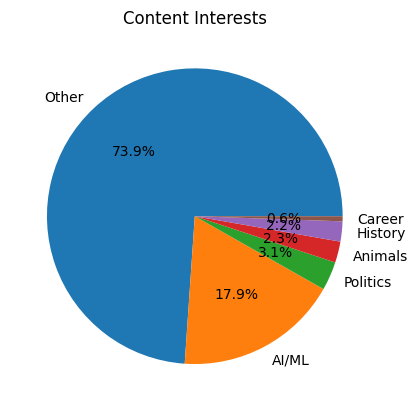

In [51]:
df["category"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.title("Content Interests")
plt.ylabel("")
plt.show()

In [52]:
print(df["time"].min())
print(df["time"].max())

2026-05-02 06:46:38.351000+00:00
2026-05-22 07:19:09.868000+00:00


In [53]:
df["year"] = df["time"].dt.year

print(df["year"].value_counts().sort_index())

year
2026    4500
Name: count, dtype: int64


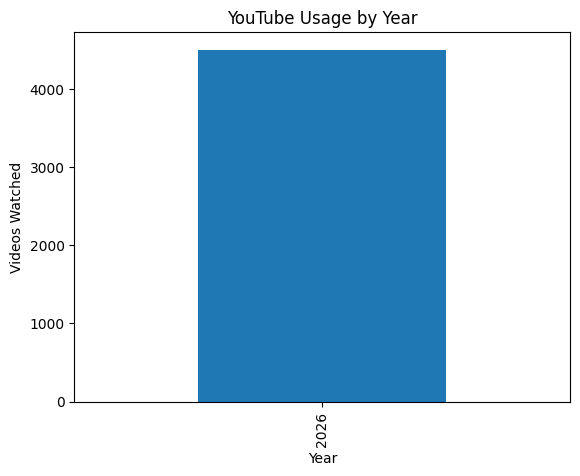

In [54]:
yearly = df["year"].value_counts().sort_index()

yearly.plot(kind="bar")

plt.title("YouTube Usage by Year")
plt.xlabel("Year")
plt.ylabel("Videos Watched")

plt.show()

In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [56]:
df.head()

,title_clean,channel,time,titleUrl,hour,date,day,category,year
0,মাদ্রাসায় Vande Mataram ! 'আমরা সিদ্ধান্ত মানব...,Aaj Tak Bangla,2026-05-22 07:19:09.868000+00:00,https://www.youtube.com/watch?v=__9pXNTYb3E,7,2026-05-22,Friday,Other,2026
1,😭BLURRED COPIES+SITE NOT WORKING 💔#cbse #cbsec...,Shree,2026-05-22 07:18:28.031000+00:00,https://www.youtube.com/watch?v=3kptOVnxEsY,7,2026-05-22,Friday,Other,2026
2,Bengal Makes Vande Mataram Mandatory In School...,India Today,2026-05-22 07:17:45.175000+00:00,https://www.youtube.com/watch?v=WVWICiQ_paI,7,2026-05-22,Friday,Other,2026
3,Cockroach Janta Party Anthem song CJP2026,Pawan Meghwanshi official,2026-05-22 07:17:08.216000+00:00,https://www.youtube.com/watch?v=Wvqe-lIYLOE,7,2026-05-22,Friday,Other,2026
4,It's time to set Bangladesh Fielding🤣🚩 #suvend...,Bharat Matters,2026-05-22 07:16:46.124000+00:00,https://www.youtube.com/watch?v=M6pTkLSnSJ8,7,2026-05-22,Friday,Politics,2026
